In [1]:
# ============================================================
# CELL 1: Install & Import Libraries
# ============================================================

# Run this cell first if packages are not installed
# !pip install pandas numpy matplotlib seaborn tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import combinations, permutations
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")

C:\Users\user\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ All libraries imported successfully.


In [2]:
# ============================================================
# CELL 2: Load the Dataset
# ============================================================

FILE_PATH = "Food_Inspections_20240215.csv"  # Update path if needed

df = pd.read_csv(FILE_PATH, dtype=str, low_memory=False)

# Standardize column names (strip whitespace)
df.columns = df.columns.str.strip()

print(f"✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Columns ({df.shape[1]}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

✅ Dataset loaded: 267,531 rows × 17 columns

📋 Columns (17):
   1. Inspection ID
   2. DBA Name
   3. AKA Name
   4. License #
   5. Facility Type
   6. Risk
   7. Address
   8. City
   9. State
  10. Zip
  11. Inspection Date
  12. Inspection Type
  13. Results
  14. Violations
  15. Latitude
  16. Longitude
  17. Location


In [3]:
import re
import time
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from thefuzz import fuzz

# ══════════════════════════════════════════════════════════════
#  CONSTANTS
# ══════════════════════════════════════════════════════════════

# ── Geographic ────────────────────────────────────────────────
CHICAGO_LAT_MIN =  41.60
CHICAGO_LAT_MAX =  42.05
CHICAGO_LON_MIN = -88.00
CHICAGO_LON_MAX = -87.20

TARGET_STATE          = "IL"
TARGET_CITY           = "CHICAGO"
TARGET_ZIP_PREFIXES   = ("606", "607", "608")
TARGET_ZIP_LENGTH     = 5
CITY_FUZZ_THRESHOLD   = 80
DROP_NON_TARGET_CITIES = True

CITY_MANUAL_MAP = {
    "INACTIVE": "CHICAGO",
    "NAN":      "CHICAGO",
}

# ── Risk ──────────────────────────────────────────────────────
TARGET_RISKS = ["RISK 1 (HIGH)", "RISK 2 (MEDIUM)", "RISK 3 (LOW)"]

# ── Facility Type ─────────────────────────────────────────────
TYPE_DESCRIPTIONS = {
    "Bakery": "Bakery bread pastry cakes baked goods patisserie",
    "Banquet Hall": "Banquet hall event venue catering reception wedding party room",
    "Candy Store": "Candy store sweets confectionery sugar snacks chocolate gelato",
    "Caterer": "Caterer catering food service commissary kitchen prep cooking",
    "Coffee Shop": "Coffee shop cafe espresso drinks tea kiosk smoothie beverages",
    "Day Care Center (for ages less than 2)": "Day care infant toddler baby nursery under 2 years children",
    "Day Care Center (for ages 2 - 6)": "Day care preschool children ages 2 to 6 years kindergarten",
    "Day Care Center (combo, for ages less than 2 and 2 - 6 combined)": "Day care combo infant toddler preschool all ages children facility",
    "Gas Station": "Gas station fuel petrol convenience store mini mart service station",
    "Golden Diner": "Golden diner classic American diner breakfast lunch",
    "Grocery Store": "Grocery store supermarket food retail produce market butcher",
    "Hospital": "Hospital medical healthcare clinic nursing patient care",
    "Long Term Care Center (Nursing Home)": "Nursing home long term care assisted living senior elderly residential care",
    "Liquor Store": "Liquor store alcohol beer wine spirits packaged goods",
    "Mobile Food Dispenser": "Mobile food truck cart vendor pushcart dispenser frozen dessert street food",
    "Restaurant": "Restaurant dining food service eating establishment bar grill tavern pub",
    "Paleteria": "Paleteria ice cream paleta Mexican frozen treats sorbet",
    "School": "School education classroom students learning academy cafeteria charter",
    "Shelter": "Shelter homeless housing refuge non-profit aid charity social services",
    "Tavern": "Tavern bar pub lounge brewery brewpub alcohol drinks nightclub hookah",
    "Social Club": "Social club VFW hall community organization members recreation",
    "Wholesaler": "Wholesaler wholesale distributor bulk food warehouse distribution",
    "Wrigley Field Rooftop": "Wrigley field rooftop Chicago Cubs baseball stadium venue",
}

ABBREV_MAP = {
    r"\bREST\b": "RESTAURANT",        r"\bGROC\b": "GROCERY",
    r"\bLIQ\b": "LIQUOR",             r"\bMFD\b": "MOBILE FOOD DISPENSER",
    r"\bBAK\b": "BAKERY",             r"\bCAT\b": "CATERER",
    r"\bBKRY\b": "BAKERY",            r"\bDELI\b": "DELICATESSEN",
    r"\bMOBIL\b": "MOBILE",           r"\bRSTAURANT\b": "RESTAURANT",
    r"\bRESATURANT\b": "RESTAURANT",  r"\bTENT\b": "TEMPORARY",
    r"\bCOMMISARY\b": "COMMISSARY",   r"\bCOMMIASARY\b": "COMMISSARY",
    r"\bPREPACKAGE\b": "PREPACKAGED", r"\bDAYCARE\b": "DAY CARE",
    r"\bNP\b": "NON PROFIT",          r"\bVFW\b": "VETERANS SOCIAL CLUB",
    r"\bGYM\b": "FITNESS CENTER",     r"\bSPA\b": "WELLNESS CENTER",
    r"\bPUB\b": "TAVERN BAR",
}

MANUAL_OVERRIDES = {
    # "exact original Facility Type string": "Official Type",
}

CHICAGO_ADDRESS_PATTERN = re.compile(r"""
    ^
    \d+(?:-\d+)?(?:\s+\d+/\d+)?
    (?:\s+[NSEW](?:ORTH|OUTH|AST|EST)?)?
    (?:\s+[A-Z0-9\'.]+)+
    \s+(?:ST|AVE|BLVD|DR|RD|CT|LN|PL|PKWY|HWY|CIR|TER|TRL|WAY|
            MARKET|RUN|ROW|PATH|WALK|LOOP|XING|PASS|SQ|EXPY|FRWY)
    (?:\s+(?:APT|STE|UNIT|FL|FLOOR|BLDG|RM|\#|LBBY)[\s\w\#-]*)?
    $
""", re.VERBOSE)


# ══════════════════════════════════════════════════════════════
#  STEP 1 — Risk
#  Drops rows whose Risk value is not in TARGET_RISKS
# ══════════════════════════════════════════════════════════════

def clean_risk(df: pd.DataFrame, col="Risk") -> pd.DataFrame:
    result = df.copy()
    result[col] = result[col].astype(str).str.upper().str.strip()

    invalid_mask = ~result[col].isin(TARGET_RISKS)
    print(f"  Valid Risk rows   : {(~invalid_mask).sum():,}")
    print(f"  Dropped (invalid) : {invalid_mask.sum():,}")
    if invalid_mask.any():
        print(f"  Invalid values seen:")
        print(result.loc[invalid_mask, col].value_counts(dropna=False).to_string())

    return result[~invalid_mask].copy()


# ══════════════════════════════════════════════════════════════
#  STEP 2 — Address
#  Cleans and flags addresses — never drops rows
# ══════════════════════════════════════════════════════════════

def clean_address(address: str) -> str:
    if not isinstance(address, str):
        return ""
    return " ".join(address.upper().split())

def is_valid_chicago_address(address: str) -> bool:
    return bool(CHICAGO_ADDRESS_PATTERN.match(address))

def clean_address_column(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()
    result["Address"] = result["Address"].apply(clean_address)
    result["address_is_valid"] = result["Address"].apply(is_valid_chicago_address)

    n_invalid = (~result["address_is_valid"]).sum()
    print(f"  Valid addresses   : {result['address_is_valid'].sum():,}")
    print(f"  Invalid addresses : {n_invalid:,} (flagged, not dropped)")
    return result


# ══════════════════════════════════════════════════════════════
#  STEP 3 — Coordinates → State → City → Zip
#  3a: Fix State/City from Location coords (no drops)
#  3b: Clean State  → drop non-IL
#  3c: Clean City   → fuzz match → drop non-Chicago
#  3d: Clean Zip    → drop invalid zip codes
# ══════════════════════════════════════════════════════════════

def parse_coord(value):
    if pd.isna(value):
        return None
    match = re.search(r"-?\d+\.\d+", str(value).strip())
    return float(match.group()) if match else None

def parse_location_pair(value):
    if pd.isna(value):
        return None, None
    nums = re.findall(r"-?\d+\.\d+", str(value).strip())
    return (float(nums[0]), float(nums[1])) if len(nums) >= 2 else (None, None)

def is_inside_chicago(lat, lon):
    if lat is None or lon is None:
        return False
    return (CHICAGO_LAT_MIN <= lat <= CHICAGO_LAT_MAX and
            CHICAGO_LON_MIN <= lon <= CHICAGO_LON_MAX)

def build_location(lat, lon):
    return f"({lat}, {lon})" if lat is not None and lon is not None else None

def clean_location_state_city_zip(df: pd.DataFrame) -> pd.DataFrame:
    result = df.copy()

    # ── 3a: Fix State/City from coordinates ───────────────────
    print("\n  [3a] Fixing State/City from Location coordinates...")
    result["_loc_lat"] = result["Location"].apply(lambda x: parse_location_pair(x)[0])
    result["_loc_lon"] = result["Location"].apply(lambda x: parse_location_pair(x)[1])

    location_present = result["_loc_lat"].notna() & result["_loc_lon"].notna()
    inside_chicago   = result.apply(
        lambda r: is_inside_chicago(r["_loc_lat"], r["_loc_lon"]), axis=1)
    fix_mask = location_present & inside_chicago

    state_needs_fix = fix_mask & (
        result["State"].isna() |
        (result["State"].astype(str).str.strip().str.upper() != "IL"))
    city_needs_fix = fix_mask & (
        result["City"].isna() |
        (result["City"].astype(str).str.strip().str.upper() != "CHICAGO"))

    result.loc[fix_mask, "State"] = "IL"
    result.loc[fix_mask, "City"]  = "CHICAGO"
    print(f"  State corrected to IL      : {state_needs_fix.sum():,}")
    print(f"  City corrected to CHICAGO  : {city_needs_fix.sum():,}")

    # Fill null Locations with IL average
    result["_lat_f"] = result["Latitude"].apply(parse_coord)
    result["_lon_f"] = result["Longitude"].apply(parse_coord)
    valid_coords = result["_lat_f"].notna() & result["_lon_f"].notna()
    il_avg_lat   = round(result.loc[valid_coords, "_lat_f"].mean(), 6)
    il_avg_lon   = round(result.loc[valid_coords, "_lon_f"].mean(), 6)
    loc_null_mask = (
        result["Location"].isna() |
        result["Location"].astype(str).str.strip().isin(["", "nan"]))
    result.loc[loc_null_mask, "Location"]  = build_location(il_avg_lat, il_avg_lon)
    result.loc[loc_null_mask, "Latitude"]  = il_avg_lat
    result.loc[loc_null_mask, "Longitude"] = il_avg_lon
    print(f"  Null Locations filled      : {loc_null_mask.sum():,}  "
          f"(avg: {il_avg_lat}, {il_avg_lon})")

    result.drop(columns=["_loc_lat", "_loc_lon", "_lat_f", "_lon_f"],
                inplace=True, errors="ignore")

    # ── 3b: State — drop non-IL ───────────────────────────────
    print("\n  [3b] Dropping non-IL rows...")
    result["State"] = result["State"].astype(str).str.upper().str.strip()
    non_il = result["State"] != TARGET_STATE
    print(f"  Dropped (non-IL) : {non_il.sum():,}")
    result = result[~non_il].copy()

    # ── 3c: City — manual map + fuzz + optional drop ──────────
    print("\n  [3c] Cleaning City...")
    result["City"] = result["City"].astype(str).str.upper().str.strip()
    result["City"] = result["City"].replace(CITY_MANUAL_MAP)

    def apply_fuzz(city_val):
        if city_val == TARGET_CITY:
            return city_val
        return TARGET_CITY if fuzz.ratio(city_val, TARGET_CITY) >= CITY_FUZZ_THRESHOLD else city_val

    result["City"] = result["City"].apply(apply_fuzz)

    non_chicago = result["City"] != TARGET_CITY
    print(f"  Non-Chicago rows : {non_chicago.sum():,}  "
          f"({'dropping' if DROP_NON_TARGET_CITIES else 'keeping'})")
    if DROP_NON_TARGET_CITIES:
        result = result[~non_chicago].copy()

    # ── 3d: Zip ───────────────────────────────────────────────
    print("\n  [3d] Cleaning Zip...")
    result["Zip"] = (result["Zip"].astype(str)
                     .str.replace(r"\.0$", "", regex=True)
                     .str.upper().str.strip())
    invalid_zip = ~(
        result["Zip"].str.startswith(TARGET_ZIP_PREFIXES, na=False) &
        (result["Zip"].str.len() == TARGET_ZIP_LENGTH))
    print(f"  Dropped (invalid Zip) : {invalid_zip.sum():,}")
    result = result[~invalid_zip].copy()

    return result.reset_index(drop=True)


# ══════════════════════════════════════════════════════════════
#  STEP 4 — Facility Type NLP
#  Never drops rows
# ══════════════════════════════════════════════════════════════

def preprocess_facility_type(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).upper().strip()
    for pattern, replacement in ABBREV_MAP.items():
        text = re.sub(pattern, replacement, text)
    text = re.sub(r"[/\-]", " ", text)
    text = re.sub(r"[^A-Z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def clean_facility_type_column(df: pd.DataFrame, model: SentenceTransformer) -> pd.DataFrame:
    result = df.copy()

    official_labels     = list(TYPE_DESCRIPTIONS.keys())
    official_embeddings = model.encode(
        list(TYPE_DESCRIPTIONS.values()), show_progress_bar=False)

    unique_vals   = result["Facility Type"].dropna().unique().tolist()
    preprocessed  = [preprocess_facility_type(v) for v in unique_vals]
    raw_embeddings = model.encode(preprocessed, show_progress_bar=True, batch_size=64)
    sim_matrix    = cosine_similarity(raw_embeddings, official_embeddings)

    lookup = {}
    for i, raw_val in enumerate(unique_vals):
        score      = float(sim_matrix[i].max())
        matched    = official_labels[sim_matrix[i].argmax()]
        confidence = "high" if score >= 0.75 else "medium" if score >= 0.50 else "low"
        lookup[raw_val] = {
            "matched":    MANUAL_OVERRIDES.get(raw_val, matched),
            "score":      round(score, 4),
            "confidence": confidence,
        }

    result["Facility Type Original"]   = result["Facility Type"]
    result["Facility Type"]            = result["Facility Type Original"].map(
        lambda x: lookup.get(x, {}).get("matched", x))
    result["Facility Type Score"]      = result["Facility Type Original"].map(
        lambda x: lookup.get(x, {}).get("score", 0.0))
    result["Facility Type Confidence"] = result["Facility Type Original"].map(
        lambda x: lookup.get(x, {}).get("confidence", "unknown"))

    mapping_df = pd.DataFrame([
        {"Original": r, "Matched to": i["matched"],
         "Score": i["score"], "Confidence": i["confidence"]}
        for r, i in sorted(lookup.items(), key=lambda x: x[1]["score"], reverse=True)
    ])
    low_conf = mapping_df[mapping_df["Confidence"] == "low"]
    if not low_conf.empty:
        print(f"\n  ⚠️  {len(low_conf)} low-confidence matches — review:")
        print(low_conf.to_string(index=False))
    print(f"\n  Confidence breakdown:")
    print(mapping_df["Confidence"].value_counts().to_string())

    return result


# ══════════════════════════════════════════════════════════════
#  MASTER PIPELINE
# ══════════════════════════════════════════════════════════════

def clean_dataframe(raw_df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleaning order and what each step drops:

    Step 1 — Risk        : drops rows with invalid Risk values
    Step 2 — Address     : flags invalid addresses (no drops)
    Step 3 — Coords/Geo  : coord correction (no drops)
                           drops non-IL State
                           drops non-Chicago City (if DROP_NON_TARGET_CITIES)
                           drops invalid Zip codes
    Step 4 — Facility Type: NLP remapping (no drops)
    """
    start      = time.time()
    rows_start = len(raw_df)

    print("── Step 1: Risk ─────────────────────────────────────────")
    result = clean_risk(raw_df)

    print("\n── Step 2: Address ──────────────────────────────────────")
    result = clean_address_column(result)

    print("\n── Step 3: Location / State / City / Zip ────────────────")
    result = clean_location_state_city_zip(result)

    print("\n── Step 4: Facility Type NLP ────────────────────────────")
    print("  Loading model...")
    model  = SentenceTransformer("all-MiniLM-L6-v2")
    result = clean_facility_type_column(result, model)

    print(f"\n{'═'*65}")
    print(f"  PIPELINE COMPLETE  ({time.time() - start:.1f}s)")
    print(f"{'═'*65}")
    print(f"  Rows in            : {rows_start:,}")
    print(f"  Rows out           : {len(result):,}")
    print(f"  Total dropped      : {rows_start - len(result):,}")
    print(f"\n  Drop breakdown:")
    print(f"    Step 1 Risk      : invalid Risk value")
    print(f"    Step 3 State     : State != IL (after coord correction)")
    print(f"    Step 3 City      : City != CHICAGO (after fuzz match)")
    print(f"    Step 3 Zip       : invalid Chicago zip prefix/length")
    print(f"\n  No drops in:")
    print(f"    Step 2 Address   : {(~result['address_is_valid']).sum():,} flagged in address_is_valid")

    print(f"    Step 4 Facility  : NLP remapping only")
    return result.reset_index(drop=True)


# ── Run ───────────────────────────────────────────────────────
df = clean_dataframe(df)

── Step 1: Risk ─────────────────────────────────────────
  Valid Risk rows   : 267,398
  Dropped (invalid) : 133
  Invalid values seen:
Risk
NAN    81
ALL    52

── Step 2: Address ──────────────────────────────────────
  Valid addresses   : 249,266
  Invalid addresses : 18,132 (flagged, not dropped)

── Step 3: Location / State / City / Zip ────────────────

  [3a] Fixing State/City from Location coordinates...
  State corrected to IL      : 59
  City corrected to CHICAGO  : 270
  Null Locations filled      : 920  (avg: 41.880734, -87.676429)

  [3b] Dropping non-IL rows...
  Dropped (non-IL) : 11

  [3c] Cleaning City...
  Non-Chicago rows : 195  (dropping)

  [3d] Cleaning Zip...
  Dropped (invalid Zip) : 54

── Step 4: Facility Type NLP ────────────────────────────
  Loading model...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]


  ⚠️  229 low-confidence matches — review:
                              Original                                                       Matched to  Score Confidence
                        Shared Kitchen                                                          Caterer 0.4994        low
                      employee kitchen                                                          Caterer 0.4968        low
                       CHURCH/DAY CARE Day Care Center (combo, for ages less than 2 and 2 - 6 combined) 0.4965        low
                             CAFETERIA                                                           School 0.4963        low
                             cafeteria                                                           School 0.4963        low
                             Cafeteria                                                           School 0.4963        low
                          smoothie bar                                                      Coffee Sho

In [4]:
# ============================================================
# CELL 3: Dataset Overview & Basic Stats
# ============================================================

print("=" * 65)
print("  DATASET OVERVIEW")
print("=" * 65)

overview = pd.DataFrame({
    "Column": df.columns,
    "Non-Null Count": df.notna().sum().values,
    "Null Count": df.isna().sum().values,
    "Null %": (df.isna().mean() * 100).round(2).values,
    "Unique Values": df.nunique().values,
    "Sample Value": [df[c].dropna().iloc[0] if df[c].notna().any() else "N/A" for c in df.columns]
})

overview.index = range(1, len(overview) + 1)
display(overview)

  DATASET OVERVIEW


,Column,Non-Null Count,Null Count,Null %,Unique Values,Sample Value
1,Inspection ID,267138,0,0.00,267138,2589375
2,DBA Name,267138,0,0.00,31990,PERFECT BEGINNINGS CHILD DEVELOPMENT CENTER
3,AKA Name,264723,2415,0.90,30463,PERFECT BEGINNINGS CHILD DEVELOPMENT CENTER
4,License #,267120,18,0.01,44315,2385784
5,Facility Type,262125,5013,1.88,23,Day Care Center (for ages less than 2)
6,Risk,267138,0,0.00,3,RISK 1 (HIGH)
7,Address,267138,0,0.00,19321,1500 W 119TH ST
8,City,267138,0,0.00,1,CHICAGO
9,State,267138,0,0.00,1,IL
10,Zip,267138,0,0.00,62,60643


In [5]:
# ============================================================
# CELL 4: Core IND Engine
# ============================================================

def compute_ind(df: pd.DataFrame,
                include_nulls: bool = False,
                min_coverage: float = 0.0) -> pd.DataFrame:
    """
    Compute all pairwise Inclusion Dependencies (INDs) between columns.

    An IND A ⊆ B holds when every value in column A exists in column B.

    Parameters
    ----------
    df            : Input DataFrame (all columns treated as string)
    include_nulls : If True, NaN counts as a value that must be matched
    min_coverage  : Only return INDs with coverage >= this threshold (0–1)

    Returns
    -------
    DataFrame with columns:
        dependent   – the "child" column (A)
        referenced  – the "parent" column (B)
        dep_unique  – unique value count in A
        ref_unique  – unique value count in B
        matched     – values in A that appear in B
        coverage    – matched / dep_unique  (1.0 = perfect IND)
        is_exact    – True if coverage == 1.0
        is_trivial  – True if dep_unique == ref_unique == matched (same sets)
    """
    results = []
    columns = df.columns.tolist()

    # Pre-compute value sets for each column (fast lookup)
    value_sets = {}
    for col in columns:
        if include_nulls:
            value_sets[col] = set(df[col].astype(str))
        else:
            value_sets[col] = set(df[col].dropna().astype(str))

    total_pairs = len(columns) * (len(columns) - 1)

    with tqdm(total=total_pairs, desc="Computing INDs", unit="pair") as pbar:
        for dep in columns:
            dep_vals = value_sets[dep]
            dep_unique = len(dep_vals)

            for ref in columns:
                if dep == ref:
                    pbar.update(1)
                    continue

                ref_vals = value_sets[ref]
                ref_unique = len(ref_vals)

                matched = len(dep_vals & ref_vals)

                coverage = matched / dep_unique if dep_unique > 0 else 0.0

                if coverage >= min_coverage:
                    results.append({
                        "dependent":  dep,
                        "referenced": ref,
                        "dep_unique": dep_unique,
                        "ref_unique": ref_unique,
                        "matched":    matched,
                        "coverage":   round(coverage, 6),
                        "is_exact":   coverage == 1.0,
                        "is_trivial": (dep_unique == ref_unique == matched)
                    })

                pbar.update(1)

    result_df = pd.DataFrame(results)
    result_df.sort_values(["coverage", "dep_unique"], ascending=[False, True], inplace=True)
    result_df.reset_index(drop=True, inplace=True)
    return result_df


print("✅ IND engine defined.")

✅ IND engine defined.


In [6]:
# ============================================================
# CELL 5: Run the IND Analysis
# ============================================================

print("🚀 Running Inclusion Dependency analysis...\n")

ind_results = compute_ind(
    df,
    include_nulls=False,   # Set True to treat NaN as a matchable value
    min_coverage=0.0       # Return ALL pairs; filter later
)

print(f"\n✅ Analysis complete. {len(ind_results):,} column pairs evaluated.")
print(f"   • Exact INDs (coverage = 1.0)  : {ind_results['is_exact'].sum():>4}")
print(f"   • Strong INDs (coverage ≥ 0.9) : {(ind_results['coverage'] >= 0.9).sum():>4}")
print(f"   • Partial INDs (0.5–0.9)       : {((ind_results['coverage'] >= 0.5) & (ind_results['coverage'] < 0.9)).sum():>4}")
print(f"   • Weak INDs (< 0.5)            : {(ind_results['coverage'] < 0.5).sum():>4}")

🚀 Running Inclusion Dependency analysis...



Computing INDs:   0%|          | 0/420 [00:00<?, ?pair/s]


✅ Analysis complete. 420 column pairs evaluated.
   • Exact INDs (coverage = 1.0)  :    0
   • Strong INDs (coverage ≥ 0.9) :    0
   • Partial INDs (0.5–0.9)       :    3
   • Weak INDs (< 0.5)            :  417


In [7]:
# ============================================================
# CELL 6: View Exact INDs (coverage = 1.0)
# ============================================================

exact_inds = ind_results[ind_results["is_exact"]].copy()

print(f"🎯 EXACT INCLUSION DEPENDENCIES  (A ⊆ B, coverage = 100%)")
print(f"   {len(exact_inds)} found\n")

if not exact_inds.empty:
    display(exact_inds[["dependent", "referenced", "dep_unique", "ref_unique", "matched", "coverage"]])
else:
    print("   No exact INDs found.")

🎯 EXACT INCLUSION DEPENDENCIES  (A ⊆ B, coverage = 100%)
   0 found

   No exact INDs found.


In [8]:
# ============================================================
# CELL 7: View Strong INDs (coverage ≥ 0.9)
# ============================================================

strong_inds = ind_results[ind_results["coverage"] >= 0.9].copy()

print(f"💪 STRONG INCLUSION DEPENDENCIES  (coverage ≥ 90%)")
print(f"   {len(strong_inds)} found\n")

display(strong_inds[["dependent", "referenced", "dep_unique", "ref_unique", "matched", "coverage", "is_exact"]]
        .head(30))

💪 STRONG INCLUSION DEPENDENCIES  (coverage ≥ 90%)
   0 found



,dependent,referenced,dep_unique,ref_unique,matched,coverage,is_exact


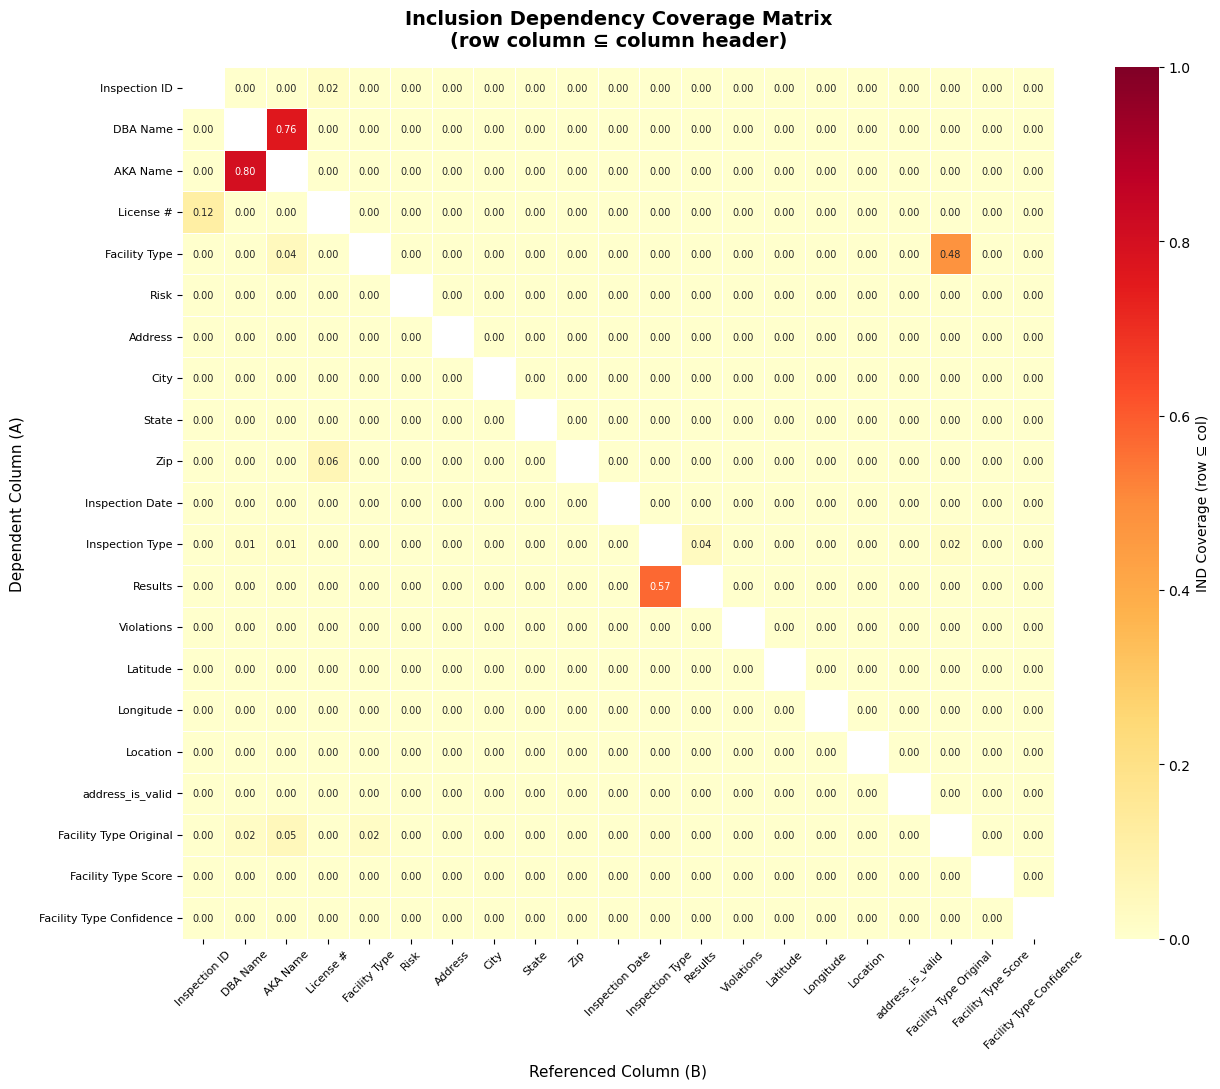

💾 Saved: ind_coverage_heatmap.png


In [9]:
# ============================================================
# CELL 8: Full IND Coverage Matrix (Heatmap)
# ============================================================

cols = df.columns.tolist()
n = len(cols)

# Build pivot matrix
coverage_matrix = ind_results.pivot(
    index="dependent", columns="referenced", values="coverage"
).reindex(index=cols, columns=cols)

# Fill diagonal with 1.0 (self-reference)
np.fill_diagonal(coverage_matrix.values, 1.0)

fig, ax = plt.subplots(figsize=(14, 11))

mask = np.eye(n, dtype=bool)   # Mask the diagonal

sns.heatmap(
    coverage_matrix.astype(float),
    ax=ax,
    mask=mask,
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.4,
    linecolor="white",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 7},
    square=True,
    cbar_kws={"label": "IND Coverage (row ⊆ col)"}
)

ax.set_title("Inclusion Dependency Coverage Matrix\n(row column ⊆ column header)",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Referenced Column (B)", fontsize=11, labelpad=10)
ax.set_ylabel("Dependent Column (A)", fontsize=11, labelpad=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig("ind_coverage_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: ind_coverage_heatmap.png")

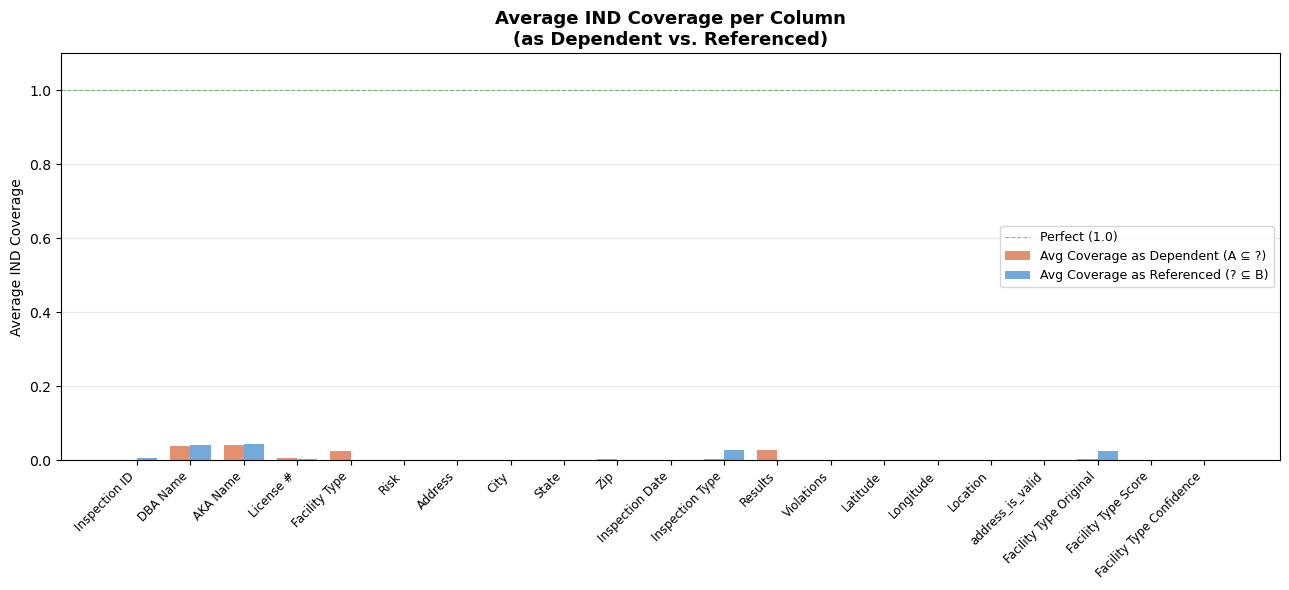

💾 Saved: ind_column_coverage_bar.png


In [10]:
# ============================================================
# CELL 9: IND Coverage Bar Chart per Column
# ============================================================

# Average coverage when column is "dependent"
avg_as_dep = (ind_results.groupby("dependent")["coverage"]
              .mean()
              .reindex(cols)
              .rename("Avg Coverage as Dependent (A)"))

# Average coverage when column is "referenced"
avg_as_ref = (ind_results.groupby("referenced")["coverage"]
              .mean()
              .reindex(cols)
              .rename("Avg Coverage as Referenced (B)"))

summary_df = pd.concat([avg_as_dep, avg_as_ref], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(cols))
width = 0.38

bars1 = ax.bar(x - width/2, summary_df["Avg Coverage as Dependent (A)"],
               width, label="Avg Coverage as Dependent (A ⊆ ?)", color="#E07B54", alpha=0.85)
bars2 = ax.bar(x + width/2, summary_df["Avg Coverage as Referenced (B)"],
               width, label="Avg Coverage as Referenced (? ⊆ B)", color="#5B9BD5", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=8.5)
ax.set_ylabel("Average IND Coverage", fontsize=10)
ax.set_title("Average IND Coverage per Column\n(as Dependent vs. Referenced)",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color="green", linestyle="--", linewidth=0.8, alpha=0.5, label="Perfect (1.0)")
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ind_column_coverage_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: ind_column_coverage_bar.png")

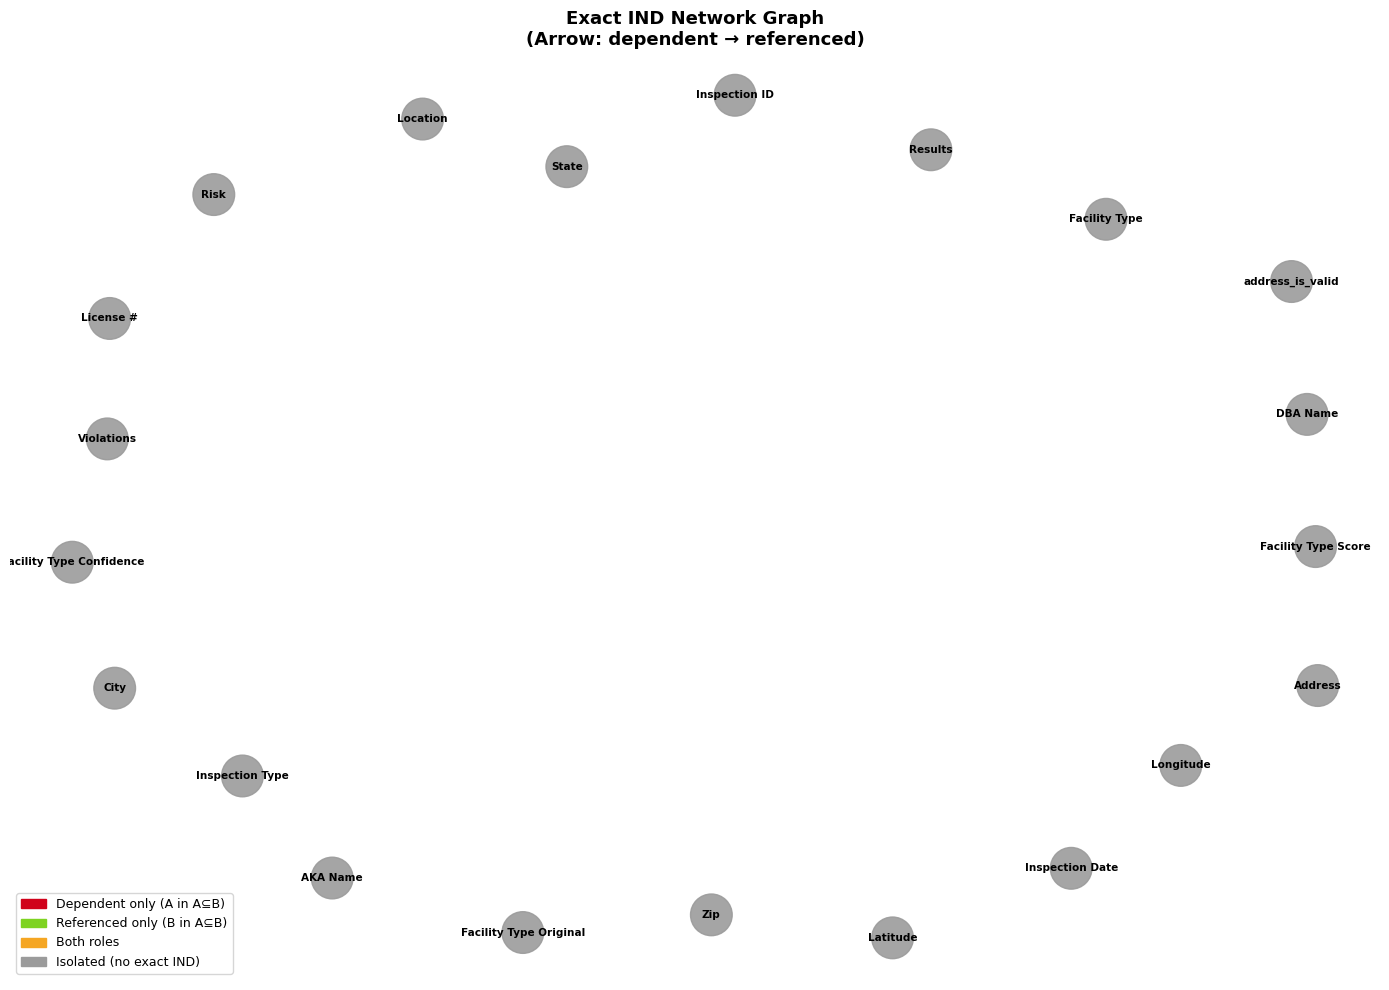

💾 Saved: ind_network_graph.png


In [11]:
# ============================================================
# CELL 10: IND Network Graph (Exact INDs)
# ============================================================

try:
    import networkx as nx
    from matplotlib.lines import Line2D

    G = nx.DiGraph()
    G.add_nodes_from(cols)

    for _, row in exact_inds.iterrows():
        if not row["is_trivial"]:
            G.add_edge(row["dependent"], row["referenced"],
                       weight=row["coverage"],
                       matched=row["matched"])

    fig, ax = plt.subplots(figsize=(14, 10))

    pos = nx.spring_layout(G, seed=42, k=2.5)

    # Color nodes by degree
    node_colors = []
    for node in G.nodes():
        in_d  = G.in_degree(node)
        out_d = G.out_degree(node)
        if in_d > 0 and out_d > 0:
            node_colors.append("#F5A623")   # both
        elif in_d > 0:
            node_colors.append("#7ED321")   # referenced
        elif out_d > 0:
            node_colors.append("#D0021B")   # dependent
        else:
            node_colors.append("#9B9B9B")   # isolated

    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=900, ax=ax, alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_size=7.5, font_weight="bold", ax=ax)
    nx.draw_networkx_edges(G, pos, ax=ax,
                           arrowstyle="->", arrowsize=18,
                           edge_color="#444444", width=1.5, alpha=0.7,
                           connectionstyle="arc3,rad=0.08")

    legend_elements = [
        mpatches.Patch(color="#D0021B", label="Dependent only (A in A⊆B)"),
        mpatches.Patch(color="#7ED321", label="Referenced only (B in A⊆B)"),
        mpatches.Patch(color="#F5A623", label="Both roles"),
        mpatches.Patch(color="#9B9B9B", label="Isolated (no exact IND)"),
    ]
    ax.legend(handles=legend_elements, loc="lower left", fontsize=9)
    ax.set_title("Exact IND Network Graph\n(Arrow: dependent → referenced)",
                 fontsize=13, fontweight="bold")
    ax.axis("off")

    plt.tight_layout()
    plt.savefig("ind_network_graph.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("💾 Saved: ind_network_graph.png")

except ImportError:
    print("⚠️  networkx not installed. Run:  pip install networkx")

In [12]:
# ============================================================
# CELL 11: Symmetric IND Pairs (Bidirectional ↔ relationships)
# ============================================================

# A ⊆ B AND B ⊆ A  →  A and B have the same value set (functionally equivalent)

exact_set = set(zip(exact_inds["dependent"], exact_inds["referenced"]))
symmetric = [
    (a, b) for (a, b) in exact_set
    if (b, a) in exact_set and a < b   # avoid duplicates
]

print(f"↔️  SYMMETRIC INDs  (A ⊆ B  AND  B ⊆ A  →  identical value sets): {len(symmetric)}\n")

if symmetric:
    sym_df = pd.DataFrame(symmetric, columns=["Column A", "Column B"])
    for _, r in sym_df.iterrows():
        va = ind_results[(ind_results.dependent == r["Column A"]) &
                         (ind_results.referenced == r["Column B"])]["dep_unique"].values[0]
        print(f"  {r['Column A']}  ↔  {r['Column B']}   ({va} shared unique values)")
else:
    print("  None found.")

↔️  SYMMETRIC INDs  (A ⊆ B  AND  B ⊆ A  →  identical value sets): 0

  None found.


In [13]:
# ============================================================
# CELL 12: Per-Column IND Detail Report
# ============================================================

print("=" * 65)
print("  PER-COLUMN IND DETAIL REPORT")
print("=" * 65)

for col in cols:
    as_dep = ind_results[ind_results["dependent"] == col].nlargest(3, "coverage")
    as_ref = ind_results[ind_results["referenced"] == col].nlargest(3, "coverage")

    print(f"\n📌 Column: [{col}]  ({df[col].nunique()} unique values)")

    if not as_dep.empty:
        print("   ↳ Best referenced columns (this col ⊆ ?):")
        for _, r in as_dep.iterrows():
            bar = "█" * int(r["coverage"] * 20)
            print(f"      {r['referenced']:25s}  coverage={r['coverage']:.3f}  |{bar:<20}|")
    else:
        print("   ↳ No IND found as dependent.")

    if not as_ref.empty:
        print("   ↳ Best dependent columns (? ⊆ this col):")
        for _, r in as_ref.iterrows():
            bar = "█" * int(r["coverage"] * 20)
            print(f"      {r['dependent']:25s}  coverage={r['coverage']:.3f}  |{bar:<20}|")
    else:
        print("   ↳ No column includes into this one.")

  PER-COLUMN IND DETAIL REPORT

📌 Column: [Inspection ID]  (267138 unique values)
   ↳ Best referenced columns (this col ⊆ ?):
      License #                  coverage=0.019  |                    |
      DBA Name                   coverage=0.000  |                    |
      AKA Name                   coverage=0.000  |                    |
   ↳ Best dependent columns (? ⊆ this col):
      License #                  coverage=0.116  |██                  |
      City                       coverage=0.000  |                    |
      State                      coverage=0.000  |                    |

📌 Column: [DBA Name]  (31990 unique values)
   ↳ Best referenced columns (this col ⊆ ?):
      AKA Name                   coverage=0.763  |███████████████     |
      Facility Type Original     coverage=0.000  |                    |
      Inspection Type            coverage=0.000  |                    |
   ↳ Best dependent columns (? ⊆ this col):
      AKA Name                   coverage=0.802

In [14]:
# ============================================================
# CELL 13: Export Results to CSV
# ============================================================

OUTPUT_FILE = "ind_results_food_inspections.csv"
ind_results.to_csv(OUTPUT_FILE, index=False)

print(f"✅ Full IND results exported to:  {OUTPUT_FILE}")
print(f"   {len(ind_results):,} rows  ×  {len(ind_results.columns)} columns")
print(f"\n   Columns: {list(ind_results.columns)}")

# Quick summary
print("\n📊 Coverage Distribution:")
bins = [0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
labels = ["0–10%", "10–30%", "30–50%", "50–70%", "70–90%", "90–100%"]
ind_results["coverage_bin"] = pd.cut(ind_results["coverage"], bins=bins, labels=labels, include_lowest=True)
display(ind_results["coverage_bin"].value_counts().sort_index().to_frame("# Pairs"))

✅ Full IND results exported to:  ind_results_food_inspections.csv
   420 rows  ×  8 columns

   Columns: ['dependent', 'referenced', 'dep_unique', 'ref_unique', 'matched', 'coverage', 'is_exact', 'is_trivial']

📊 Coverage Distribution:


,# Pairs
coverage_bin,
0–10%,415
10–30%,1
30–50%,1
50–70%,1
70–90%,2
90–100%,0


In [15]:
# ============================================================
# EXTENSION 1: Value-level inspection — WHY does the overlap happen?
# Run this after your main IND analysis to understand each finding.
# ============================================================

def explain_overlap(df, col_a, col_b, n=20):
    """Show the actual shared values between two columns."""
    vals_a = set(df[col_a].dropna().astype(str))
    vals_b = set(df[col_b].dropna().astype(str))
    shared = vals_a & vals_b

    print(f"\n'{col_a}'  ⊆  '{col_b}'  — {len(shared)} shared values\n")
    print(f"  Unique in A only : {len(vals_a - vals_b):>6}")
    print(f"  Shared (A ∩ B)   : {len(shared):>6}  ← these are the matches")
    print(f"  Unique in B only : {len(vals_b - vals_a):>6}")
    print(f"\n  Sample shared values:")
    for v in sorted(shared)[:n]:
        print(f"    {repr(v)}")

# Run on the meaningful pairs from your results:
explain_overlap(df, "DBA Name",       "AKA Name")
explain_overlap(df, "Results",        "Inspection Type")
explain_overlap(df, "Zip",            "Inspection ID")


'DBA Name'  ⊆  'AKA Name'  — 24418 shared values

  Unique in A only :   7572
  Shared (A ∩ B)   :  24418  ← these are the matches
  Unique in B only :   6045

  Sample shared values:
    '#1 CHOP SUEY'
    '#1 CHOP SUEY RESTAURANT'
    '#1 DELI'
    '#1 DELI, INC'
    '#1 MARKET INC.'
    '#1 WOK N ROLL'
    "'C' A CATERING AND EVENT COMPANY"
    "'LAINE'S BAKE SHOP"
    "'SWEET SUGAH' CATERING BOUTIQUE"
    '(K)  NEW  RESTAURANT'
    '1 2 3 EXPRESS'
    '1 JACKPOT MINI MART, INC.'
    '1 KARACHI CHAAT HOUSE'
    '1 N WACKER KITCHEN AND BAR'
    '1 SHOP & SAVE, INC'
    '1 STOP & SHOP INC.'
    '1,4,3,7 SOUL RESTAURANT'
    '1-94 RIBS & GRILL'
    '10 PIN  BOWLING LOUNGE'
    '10 SOUTH MARKET'

'Results'  ⊆  'Inspection Type'  — 4 shared values

  Unique in A only :      3
  Shared (A ∩ B)   :      4  ← these are the matches
  Unique in B only :    105

  Sample shared values:
    'Business Not Located'
    'No Entry'
    'Not Ready'
    'Out of Business'

'Zip'  ⊆  'Inspection ID'  

In [16]:
# ============================================================
# EXTENSION 2: Null-aware IND — separates data quality from structure
# The original engine drops nulls. This version reports what % of
# each column is null, and re-runs only on rows where BOTH columns
# have values.
# ============================================================

def null_aware_ind(df, col_a, col_b):
    """IND coverage computed only on rows where both columns are filled."""
    both_filled = df[[col_a, col_b]].dropna()
    pct_a_null = df[col_a].isna().mean() * 100
    pct_b_null = df[col_b].isna().mean() * 100
    rows_used   = len(both_filled)

    vals_a = set(both_filled[col_a].astype(str))
    vals_b = set(both_filled[col_b].astype(str))
    coverage = len(vals_a & vals_b) / len(vals_a) if vals_a else 0

    print(f"\nNull-aware IND: '{col_a}' ⊆ '{col_b}'")
    print(f"  Null rate — {col_a}: {pct_a_null:.1f}%  |  {col_b}: {pct_b_null:.1f}%")
    print(f"  Rows with both values: {rows_used:,}")
    print(f"  Coverage (on filled rows): {coverage:.4f}")

null_aware_ind(df, "DBA Name",  "AKA Name")
null_aware_ind(df, "Results",   "Inspection Type")


Null-aware IND: 'DBA Name' ⊆ 'AKA Name'
  Null rate — DBA Name: 0.0%  |  AKA Name: 0.9%
  Rows with both values: 264,723
  Coverage (on filled rows): 0.7803

Null-aware IND: 'Results' ⊆ 'Inspection Type'
  Null rate — Results: 0.0%  |  Inspection Type: 0.0%
  Rows with both values: 267,137
  Coverage (on filled rows): 0.5714


In [17]:
# ============================================================
# EXTENSION 3: Column type classifier — flag false positives automatically
# Numeric-looking string columns (Zip, Inspection ID, License #)
# should not be compared for INDs — this tags them.
# ============================================================

import re

def classify_columns(df):
    """Classify each column as: id, numeric_code, categorical, free_text, coordinate."""
    results = []
    for col in df.columns:
        series = df[col].dropna().astype(str)
        n_unique = series.nunique()
        n_total  = len(series)
        uniqueness = n_unique / n_total if n_total else 0

        # Heuristic rules
        if uniqueness > 0.95:
            col_type = "id / free_text"
        elif series.str.match(r'^\-?\d+\.\d+$').mean() > 0.9:
            col_type = "coordinate"
        elif series.str.match(r'^\d{4,10}$').mean() > 0.8:
            col_type = "numeric_code"
        elif n_unique <= 20:
            col_type = "categorical"
        elif n_unique <= 500:
            col_type = "semi-categorical"
        else:
            col_type = "free_text"

        results.append({
            "Column":     col,
            "Type":       col_type,
            "Unique":     n_unique,
            "Uniqueness": f"{uniqueness:.2%}",
            "IND useful": col_type not in ("id / free_text", "coordinate", "numeric_code")
        })

    return pd.DataFrame(results)

type_df = classify_columns(df)
display(type_df)

# Filter to only IND-meaningful columns for a cleaner re-run
useful_cols = type_df[type_df["IND useful"]]["Column"].tolist()
print(f"\nColumns worth comparing: {useful_cols}")

,Column,Type,Unique,Uniqueness,IND useful
0,Inspection ID,id / free_text,267138,100.00%,False
1,DBA Name,free_text,31990,11.98%,True
2,AKA Name,free_text,30463,11.51%,True
3,License #,numeric_code,44315,16.59%,False
4,Facility Type,semi-categorical,23,0.01%,True
5,Risk,categorical,3,0.00%,True
6,Address,free_text,19321,7.23%,True
7,City,categorical,1,0.00%,True
8,State,categorical,1,0.00%,True
9,Zip,numeric_code,62,0.02%,False



Columns worth comparing: ['DBA Name', 'AKA Name', 'Facility Type', 'Risk', 'Address', 'City', 'State', 'Inspection Date', 'Inspection Type', 'Results', 'Location', 'address_is_valid', 'Facility Type Original', 'Facility Type Confidence']


In [18]:
# ============================================================
# EXTENSION 4: Targeted re-run on meaningful columns only
# Re-run the IND engine on the filtered column set.
# ============================================================

df_filtered = df[useful_cols]
ind_filtered = compute_ind(df_filtered, min_coverage=0.0)

print("\nFiltered IND results (meaningful columns only):")
display(ind_filtered.nlargest(15, "coverage"))

Computing INDs:   0%|          | 0/182 [00:00<?, ?pair/s]


Filtered IND results (meaningful columns only):


,dependent,referenced,dep_unique,ref_unique,matched,coverage,is_exact,is_trivial
0,AKA Name,DBA Name,30463,31990,24418,0.801563,False,False
1,DBA Name,AKA Name,31990,30463,24418,0.763301,False,False
2,Results,Inspection Type,7,109,4,0.571429,False,False
3,Facility Type,Facility Type Original,23,505,11,0.478261,False,False
4,Facility Type Original,AKA Name,505,30463,24,0.047525,False,False
5,Facility Type,AKA Name,23,30463,1,0.043478,False,False
6,Inspection Type,Results,109,7,4,0.036697,False,False
7,Facility Type Original,Facility Type,505,23,11,0.021782,False,False
8,Facility Type Original,DBA Name,505,31990,10,0.019802,False,False
9,Inspection Type,Facility Type Original,109,505,2,0.018349,False,False


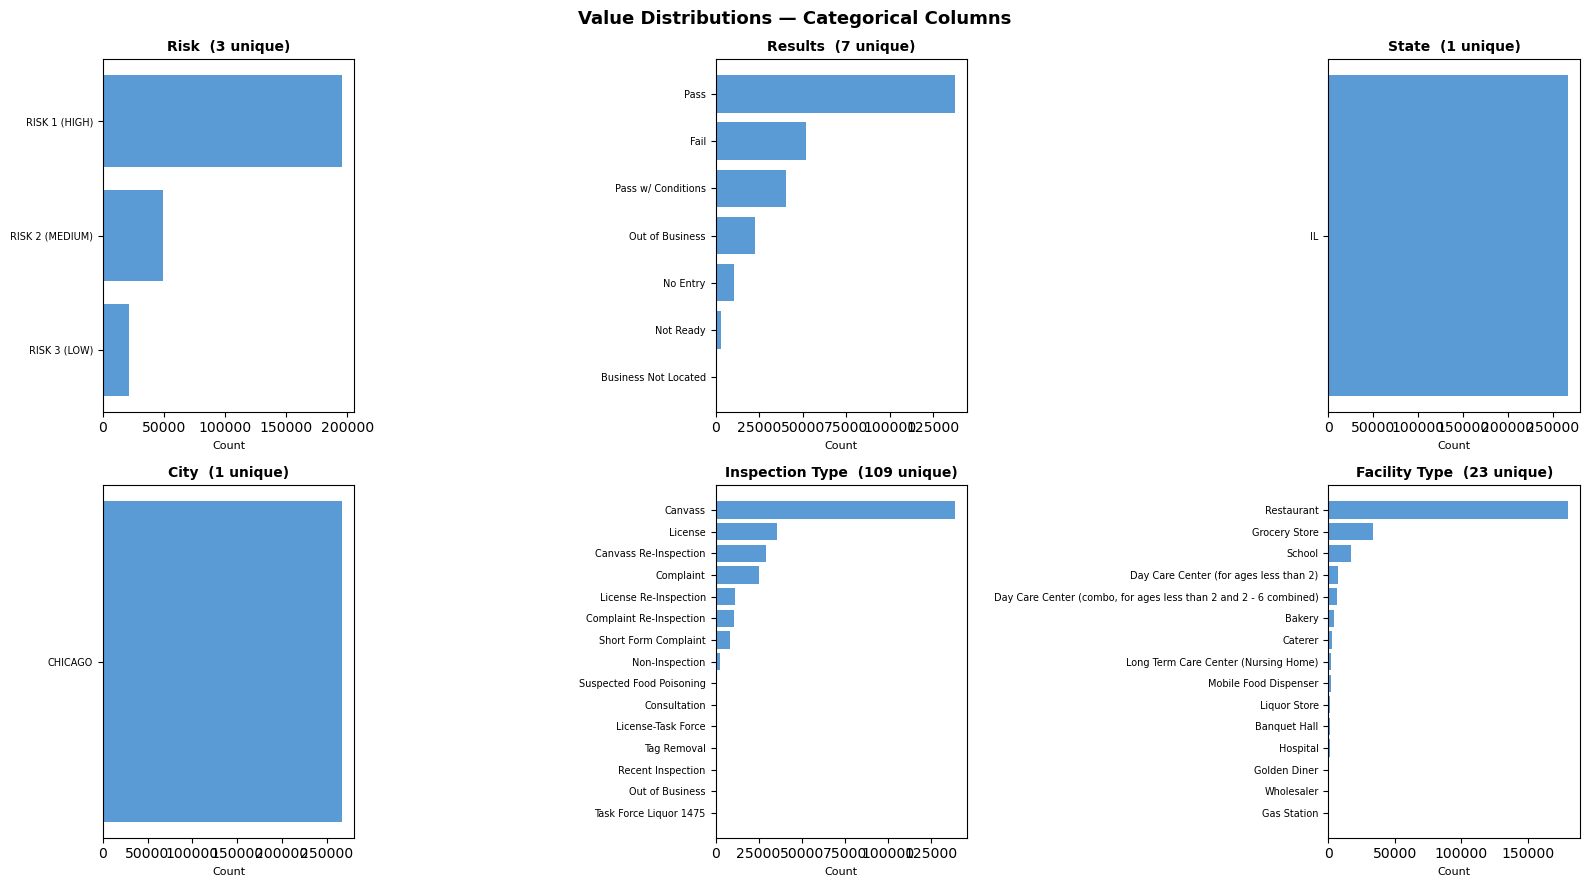

In [19]:
# ============================================================
# EXTENSION 5: Frequency analysis of categorical columns
# Understand the distribution of low-cardinality columns
# like Risk, Results, State, City, Facility Type.
# ============================================================

categorical_cols = ["Risk", "Results", "State", "City", 
                    "Inspection Type", "Facility Type"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts().head(15)
    axes[i].barh(counts.index.astype(str), counts.values, color="#5B9BD5")
    axes[i].set_title(f"{col}  ({df[col].nunique()} unique)", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Count", fontsize=8)
    axes[i].tick_params(axis='y', labelsize=7)
    axes[i].invert_yaxis()

plt.suptitle("Value Distributions — Categorical Columns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# ============================================================
# EXTENSION 6: Violations text mining — hidden structure
# Violations is the most complex column (192,923 unique strings).
# Each cell contains multiple violation codes and descriptions.
# This extracts the violation code numbers.
# ============================================================

import re

def extract_violation_codes(text):
    """Extract numeric violation codes like '1.', '14.', '32.' from a violations string."""
    if pd.isna(text):
        return []
    return re.findall(r'\b(\d+)\.\s', str(text))

df["violation_codes"] = df["Violations"].apply(extract_violation_codes)
df["violation_count"]  = df["violation_codes"].apply(len)

# Most common violation codes across all inspections
from collections import Counter
all_codes = [code for codes in df["violation_codes"] for code in codes]
top_violations = pd.DataFrame(
    Counter(all_codes).most_common(20),
    columns=["Violation Code", "Frequency"]
)

print("Top 20 most common violation codes:")
display(top_violations)

# Distribution of violation counts per inspection
print(f"\nViolation count stats:")
display(df["violation_count"].describe())

Top 20 most common violation codes:


,Violation Code,Frequency
0,34,71816
1,38,69424
2,33,65903
3,35,65524
4,55,58554
5,32,55221
6,41,38433
7,36,33194
8,47,26220
9,3,26219



Violation count stats:


count    267138.000000
mean          3.569923
std           3.780646
min           0.000000
25%           0.000000
50%           3.000000
75%           5.000000
max          45.000000
Name: violation_count, dtype: float64